In [1]:
import sys
sys.path.append('../../')
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import glob
from matplotlib.patches import Patch
import re
import tqdm

# HD comparisons with K = 3

In [2]:
names = [
    'gaussian_20',
    'gaussian_50',
    'gaussian_200',
    'gaussian_500',
    'gaussian_1000',
    
    'gaussian_20_medium',
    'gaussian_50_medium',
    'gaussian_200_medium',
    'gaussian_500_medium',
    'gaussian_1000_medium',
    
    'moon_20_medium',
    'moon_50_medium',
    'moon_200_medium',
    'moon_500_medium',
    'moon_1000_medium',

    'gamma_20',
    'gamma_50',
    'gamma_200',
    'gamma_500',
    'gamma_1000',

    'gamma_20_medium',
    'gamma_50_medium',
    'gamma_200_medium',
    'gamma_500_medium',
    'gamma_1000_medium',
    
    'moon_20_easy',
    'moon_50_easy',
    'moon_200_easy',
    'moon_500_easy',
    'moon_1000_easy',

    'moon_20',
    'moon_50',
    'moon_200',
    'moon_500',
    'moon_1000',
]

In [3]:
def build_avg_df(results):
    if isinstance(results, dict):
        results = [results]

    rows = []
    for r in results:
        # scalar metadata
        def scalar(x):
            x = np.asarray(x)
            return x.item() if x.size == 1 else x
        task_id = scalar(r["task_id"])
        informative_d = scalar(r["informative_d"])
        noise_d = scalar(r["noise_d"])
        # infer methods
        methods = [k.replace("topk_hits_", "") for k in r if k.startswith("topk_hits_")]

        for m in methods:
            topk_mean = np.mean(r[f"topk_hits_{m}"])
            topk_se = np.std(r[f'topk_hits_{m}'])/np.sqrt(len(r[f'topk_hits_{m}']))
            time_mean = np.mean(r[f"time_{m}"])
            time_se = np.std(r[f"time_{m}"])/np.sqrt(len(r[f'time_{m}']))
            try:
                ari_mean = np.mean(r[f'ari_{m}'])
                ari_se = np.std(r[f'ari_{m}'])/np.sqrt(len(r[f'ari_{m}']))
            except:
                ari_mean = 0
                ari_se = 0
                
            rows.append({
                "task_id": task_id,
                "informative_d": informative_d,
                "noise_d": noise_d,
                "method": m,
                "ari": ari_mean,
                "ari_std":ari_se,
                "topk_hits_mean": topk_mean,
                "topk_hits_std": topk_se,
                "time_mean": time_mean,
                "time_se": time_se,
            })

    return pd.DataFrame(rows)


def parse_simulation_name(out_dir):
    name = os.path.basename(out_dir)
    # print(name)
    m = re.search(r"_(20|50|200|500|1000)(?:_|$)", name)
    if m is None:
        raise ValueError(f"Cannot parse p from {name}")
        
    p = int(m.group(1))
    if 'gaussian' in name:
        source='gaussian'
        if "medium" in name:
            difficulty = "medium"
        else:
            difficulty = "easy"
    elif 'moon' in name:
        source = 'moon'
        if 'easy' in name:
            difficulty ='easy'
        elif 'medium' in name:
            difficulty = 'medium'
        else:
            difficulty = 'easy'

    elif 'gamma' in name:
        source ='gamma'
        if "medium" in name:
            difficulty='medium'
        else: 
            difficulty='easy'
    else:
        source = str(name).split('_')[0]
        return source, "easy", p
        
    return source, difficulty, p

In [4]:
base_colors = {
    "pbfi": "#277da1",
    "lrp": "#577590",
    "impacc": "#43aa8b",
    "split_cloc": "#f9c74f",
    "cloc": "#f8961e",
    "rampart": "#f94144",
    "perm": "#e377c2",
    "cshap": "#780000",
}

# dprettier labels
label_map = {
    "split_cloc": "Split-Cluster LOCO",
    "cloc": "Cluster LOCOMP",
    "rampart": "RAMPART \nCluster LOCO",    
    "pbfi": "PBFI",
    "lrp": "LRP",
    "impacc": "IMPACC",
    'perm':"Permutation",
    'cshap':"Fuzzy-KMeans SHAP"
}

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re

def get_lineplot_parentheses_labels(df_avg, source, difficulty, p_order=[20, 50, 200, 500, 1000], title='', figsize=(10, 6), save_file=None, base_clusterer='Spectral', **kwargs):
    # 1. Data Filtering
    df = df_avg[
        (df_avg.source == source) & 
        (df_avg.simulation == difficulty) & 
        (df_avg["p"].isin(p_order))
    ].copy()

    base_colors = {
        "pbfi": "#277da1", "lrp": "#577590", "impacc": "#43aa8b",
        "perm": "#e377c2", "cshap": "#780000", "cloc": "#f8961e", "rampart": "#f94144",
    }
    
    # Mapping for Internal Logic
    label_map = {
        "rampart": f"RAMPART ({base_clusterer})",   
        "cloc": f"Cluster LOCOMP ({base_clusterer})",
        "pbfi": "PBFI (KMeans)",
        "lrp": "LRP (KMeans)",
        "impacc": f"IMPACC ({base_clusterer})",
        "perm": f"Permutation ({base_clusterer})",
        "cshap": "Fuzzy C-Means (FCM)", # Added parenthetical for CSHAP
    }

    # Ensure RAMPART plots on top
    plot_order = ["pbfi", "lrp", "impacc", "perm", "cshap", "cloc", "rampart"]
    plot_order_pretty = [label_map[m] for m in plot_order]
    
    df['method_pretty'] = df['method'].map(label_map)
    df['method_pretty'] = pd.Categorical(df['method_pretty'], categories=plot_order_pretty, ordered=True)
    
    pretty_palette = {label_map.get(k, k): v for k, v in base_colors.items()}
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("white")
    
    # Plot without legend
    sns.lineplot(
        data=df, x='p', y='topk_hits_mean', hue='method_pretty', 
        palette=pretty_palette, markers=True, dashes=False,
        linewidth=4, alpha=0.8, ax=ax, legend=False
    )
    
    ax.set_xscale('log')
    ax.set_xticks(p_order)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    # 2. EXTRACT PARENTHESES AND LABEL
    last_p = max(p_order)
    
    for method_full_name in plot_order_pretty:
        method_data = df[df['method_pretty'] == method_full_name]
        if not method_data.empty:
            # Find Y position
            y_val = method_data[method_data['p'] == last_p]['topk_hits_mean'].mean()
            color = pretty_palette[method_full_name]
            
    # Styling
    ax.set_xlim(min(p_order), last_p) # Adjusted for shorter labels
    ax.set_ylabel(r"Top-$k$ Hits", fontsize=12)
    ax.set_xlabel(r"Number of Features $p$", fontsize=12)
    ax.set_title(title, pad=15)
    sns.despine()

    if save_file:
        fig.savefig(save_file, dpi=300, bbox_inches='tight')
    
    return fig, ax

## K=3, N=500

In [10]:
folder = '../scripts/K3N500/' 
out_dir_list = [os.path.join(folder, n) for n in names]

In [11]:
df_list = []
for i, out_dir in tqdm.tqdm(enumerate(out_dir_list)):
    files = (
        glob.glob(os.path.join(out_dir,"task_*", "results_task00000.npz")) ## Need to restrict to task_0:19
    )
    files = sorted(files)
    
    all_results = []
    
    for f in files:
        data = np.load(f)
        result_dict = {k: data[k] for k in data.files}
        all_results.append(result_dict)
    
    # print(f"Loaded {len(all_results)} files")
    methods = ["pbfi","lrp","impacc","split_cloc","cloc","rampart" , "perm", "cshap"] #,"shapley","rampshap"]

    mean_topk = {}
    
    for m in methods:
        try:
            stacked = np.concatenate([r[f"topk_hits_{m}"] for r in all_results])
            mean_topk[m] = np.mean(stacked)
        except: 
            pass
    df_avg = build_avg_df(all_results)

    source, difficulty, p = parse_simulation_name(out_dir)
    df_avg['source'] = source
    df_avg["simulation"] = difficulty
    df_avg["p"] = p
    
    df_list.append(df_avg)

df_avg = pd.concat(df_list, ignore_index=True)

30it [00:53,  1.79s/it]


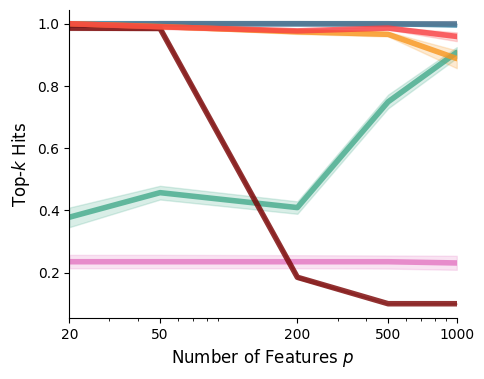

In [13]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'easy', title='', figsize=(5, 4), base_clusterer ='KMeans', save_file='../figures/supp2_GMM_easier.pdf')

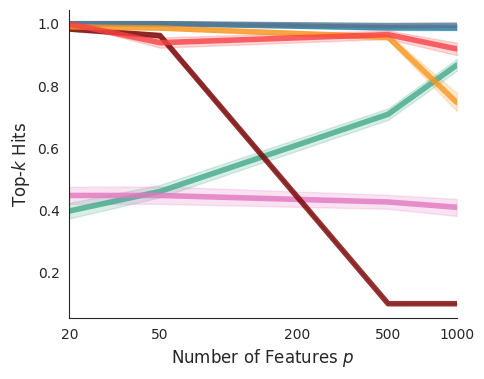

In [14]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'medium', title='', figsize=(5, 4),base_clusterer ='KMeans',  save_file='../figures/supp2_GMM_harder.pdf')

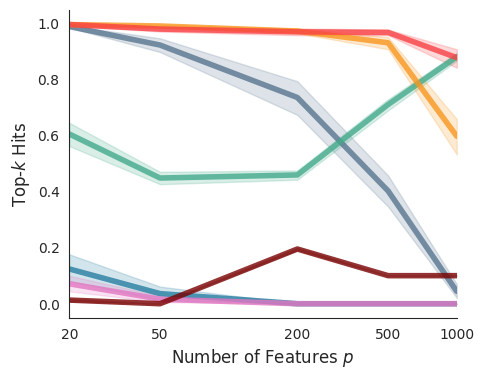

In [15]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'easy', figsize=(5, 4),base_clusterer ='Gamma Mixture',  save_file='../figures/supp2_GammaMM_easier.pdf') #  title='Gamma mixture (easier)',

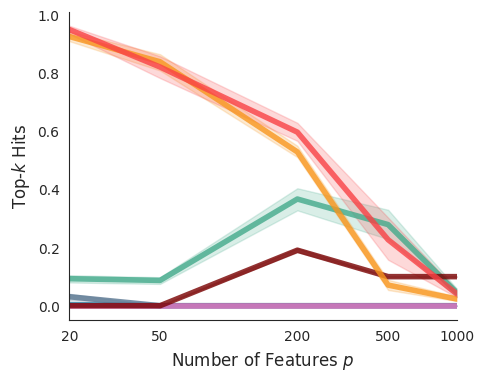

In [16]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'medium', base_clusterer ='Gamma Mixture', figsize=(5, 4), save_file='../figures/supp2_GammaMM_harder.pdf') #  title='Gamma mixture (harder)',

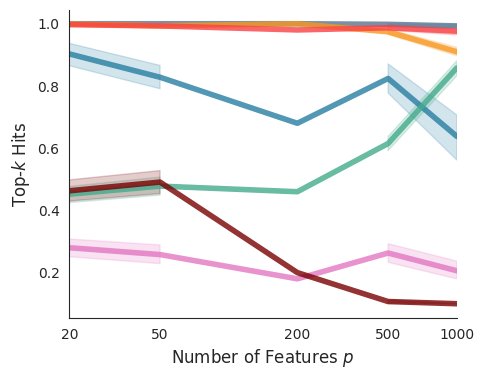

In [17]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'easy', title='', figsize=(5, 4), base_clusterer ='Spectral Clustering', save_file='../figures/supp2_MC_easier.pdf')

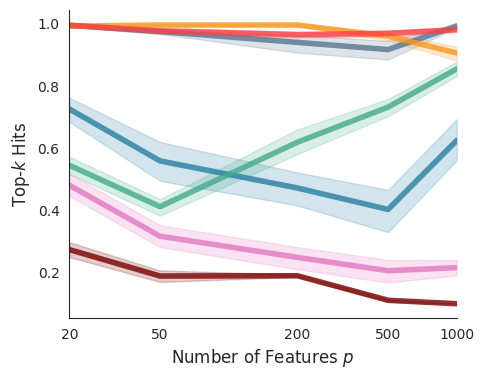

In [18]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'medium',  figsize=(5, 4),base_clusterer ='Spectral',   save_file='../figures/supp2_MC_harder.pdf')#  title='Moons and Circles (harder)',

## K=3, N=100

In [57]:
folder = '../scripts/K3N100/' 
out_dir_list = [os.path.join(folder, n) for n in names]

In [58]:
df_list = []
for i, out_dir in tqdm.tqdm(enumerate(out_dir_list)):
    files = (
        glob.glob(os.path.join(out_dir,"task_*", "results_task00000.npz")) ## Need to restrict to task_0:19
    )
    files = sorted(files)
    
    all_results = []
    
    for f in files:
        data = np.load(f)
        result_dict = {k: data[k] for k in data.files}
        all_results.append(result_dict)
    
    # print(f"Loaded {len(all_results)} files")
    methods = ["pbfi","lrp","impacc","split_cloc","cloc","rampart" , "perm", "cshap"] #,"shapley","rampshap"]

    mean_topk = {}
    
    for m in methods:
        try:
            stacked = np.concatenate([r[f"topk_hits_{m}"] for r in all_results])
            mean_topk[m] = np.mean(stacked)
        except: 
            pass
    df_avg = build_avg_df(all_results)

    source, difficulty, p = parse_simulation_name(out_dir)
    df_avg['source'] = source
    df_avg["simulation"] = difficulty
    df_avg["p"] = p
    
    df_list.append(df_avg)

df_avg = pd.concat(df_list, ignore_index=True)

35it [00:01, 17.61it/s]


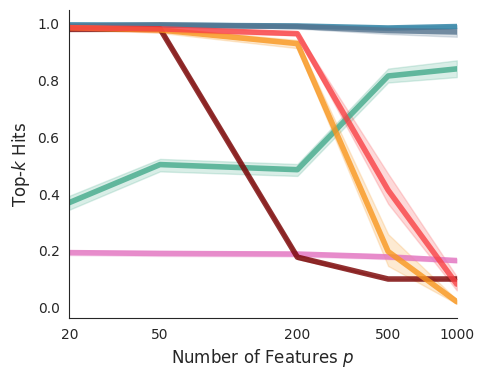

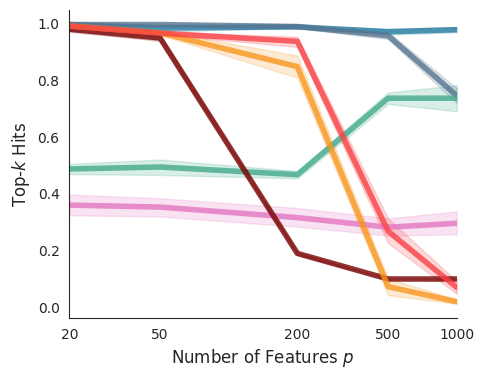

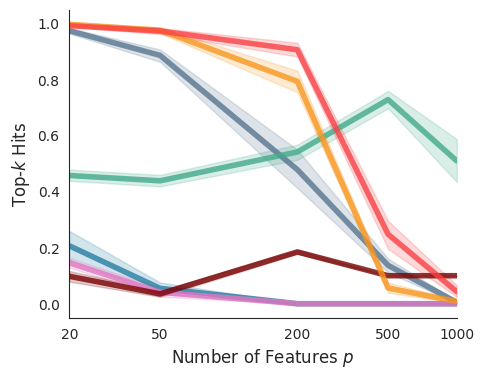

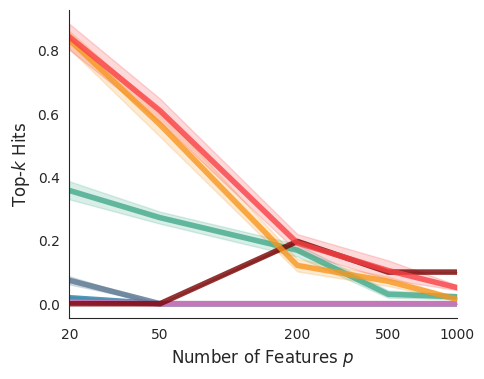

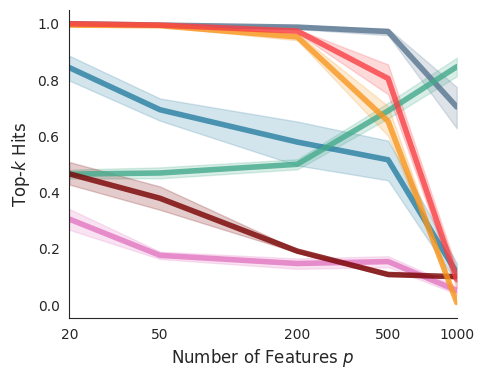

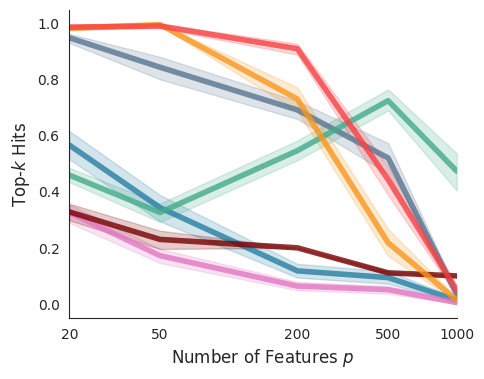

In [59]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'easy', title='', figsize=(5, 4), base_clusterer ='KMeans', save_file='../figures/supp3_GMM_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'medium', title='', figsize=(5, 4),base_clusterer ='KMeans',  save_file='../figures/supp3_GMM_harder.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'easy', figsize=(5, 4),base_clusterer ='Gamma Mixture',  save_file='../figures/supp3_GammaMM_easier.pdf') #  title='Gamma mixture (easier)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'medium', base_clusterer ='Gamma Mixture', figsize=(5, 4), save_file='../figures/supp3_GammaMM_harder.pdf') #  title='Gamma mixture (harder)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'easy', title='', figsize=(5, 4), base_clusterer ='Spectral Clustering', save_file='../figures/supp3_MC_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'medium',  figsize=(5, 4),base_clusterer ='Spectral',   save_file='../figures/supp3_MC_harder.pdf')#  title='Moons and Circles (harder)',
plt.show()

## With K=3, N=100, adaptive minipatch sizes

In [7]:
folder = '../scripts/K3N100_adaptive/' 
out_dir_list = [os.path.join(folder, n) for n in names]

In [8]:
df_list = []
for i, out_dir in tqdm.tqdm(enumerate(out_dir_list)):
    files = (
        glob.glob(os.path.join(out_dir,"task_*", "results_task00000.npz")) ## Need to restrict to task_0:19
    )
    files = sorted(files)
    
    all_results = []
    
    for f in files:
        data = np.load(f)
        result_dict = {k: data[k] for k in data.files}
        all_results.append(result_dict)
    
    # print(f"Loaded {len(all_results)} files")
    methods = ["pbfi","lrp","impacc","split_cloc","cloc","rampart" , "perm", "cshap"] #,"shapley","rampshap"]

    mean_topk = {}
    
    for m in methods:
        try:
            stacked = np.concatenate([r[f"topk_hits_{m}"] for r in all_results])
            mean_topk[m] = np.mean(stacked)
        except: 
            pass
    df_avg = build_avg_df(all_results)

    source, difficulty, p = parse_simulation_name(out_dir)
    df_avg['source'] = source
    df_avg["simulation"] = difficulty
    df_avg["p"] = p
    
    df_list.append(df_avg)

df_avg = pd.concat(df_list, ignore_index=True)

35it [00:13,  2.63it/s]


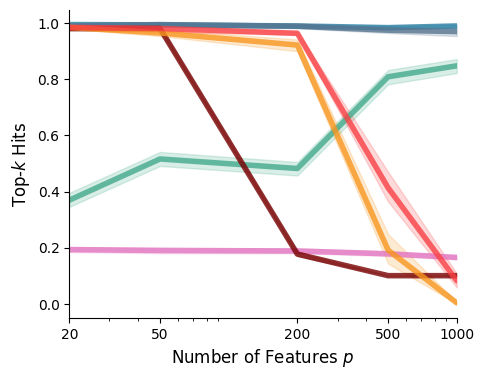

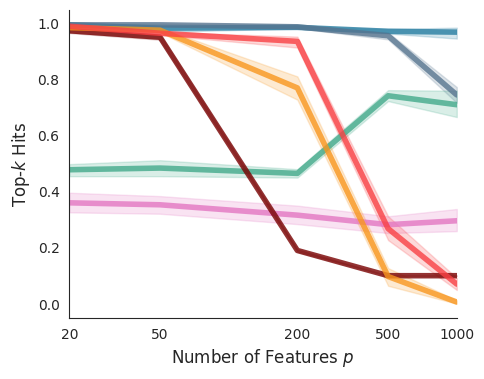

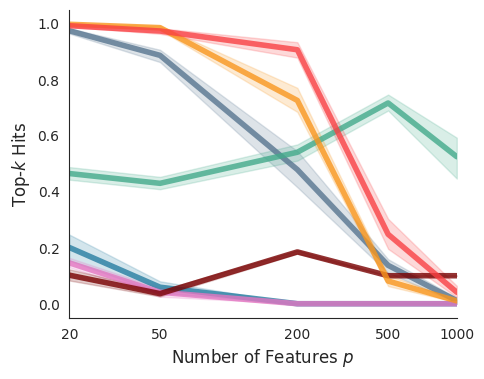

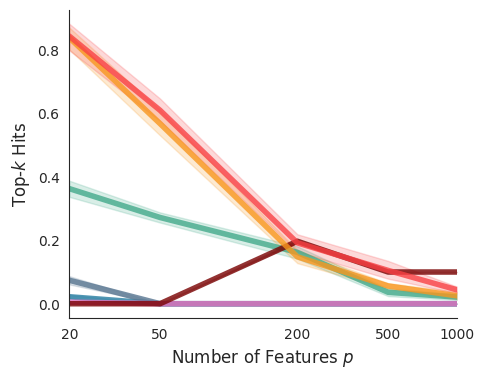

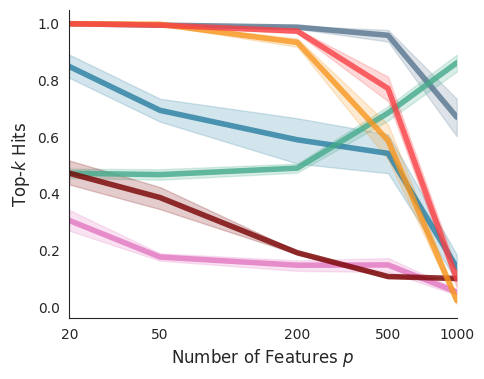

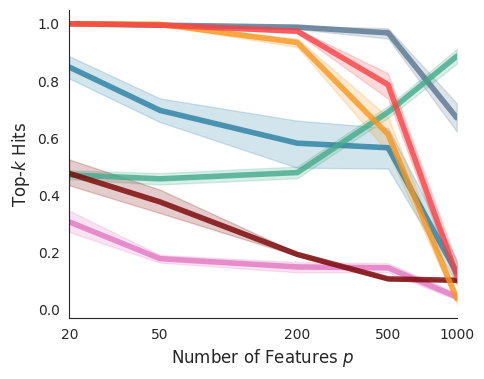

In [9]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'easy', title='', figsize=(5, 4), base_clusterer ='KMeans', save_file='../figures/supp4_GMM_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'medium', title='', figsize=(5, 4),base_clusterer ='KMeans',  save_file='../figures/supp4_GMM_harder.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'easy', figsize=(5, 4),base_clusterer ='Gamma Mixture',  save_file='../figures/supp4_GammaMM_easier.pdf') #  title='Gamma mixture (easier)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'medium', base_clusterer ='Gamma Mixture', figsize=(5, 4), save_file='../figures/supp4_GammaMM_harder.pdf') #  title='Gamma mixture (harder)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'easy', title='', figsize=(5, 4), base_clusterer ='Spectral Clustering', save_file='../figures/supp4_MC_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'medium',  figsize=(5, 4),base_clusterer ='Spectral',   save_file='../figures/supp4_MC_harder.pdf')#  title='Moons and Circles (harder)',
plt.show()

## K=3, N=300

In [6]:
folder = '../scripts/K3N300/' 
out_dir_list = [os.path.join(folder, n) for n in names]

In [7]:
df_list = []
for i, out_dir in tqdm.tqdm(enumerate(out_dir_list)):
    files = (
        glob.glob(os.path.join(out_dir,"task_*", "results_task00000.npz")) ## Need to restrict to task_0:19
    )
    files = sorted(files)
    
    all_results = []
    
    for f in files:
        data = np.load(f)
        result_dict = {k: data[k] for k in data.files}
        all_results.append(result_dict)
    
    # print(f"Loaded {len(all_results)} files")
    methods = ["pbfi","lrp","impacc","split_cloc","cloc","rampart" , "perm", "cshap"] #,"shapley","rampshap"]

    mean_topk = {}
    
    for m in methods:
        try:
            stacked = np.concatenate([r[f"topk_hits_{m}"] for r in all_results])
            mean_topk[m] = np.mean(stacked)
        except: 
            pass
    df_avg = build_avg_df(all_results)

    source, difficulty, p = parse_simulation_name(out_dir)
    df_avg['source'] = source
    df_avg["simulation"] = difficulty
    df_avg["p"] = p
    
    df_list.append(df_avg)

df_avg = pd.concat(df_list, ignore_index=True)

35it [00:20,  1.70it/s]


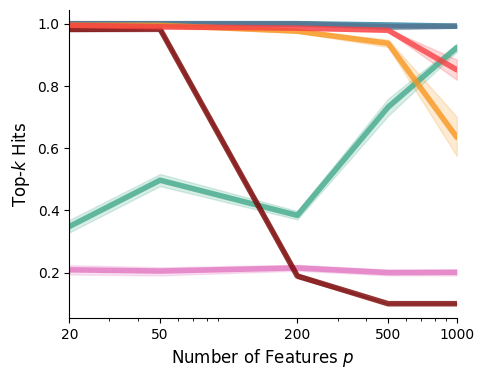

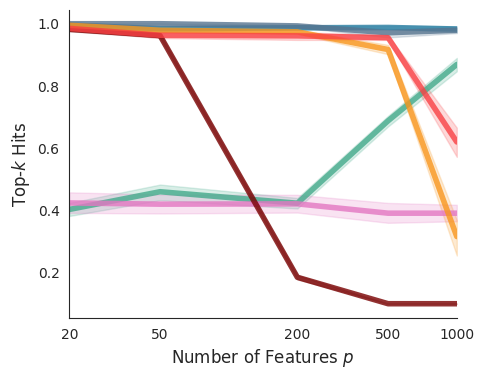

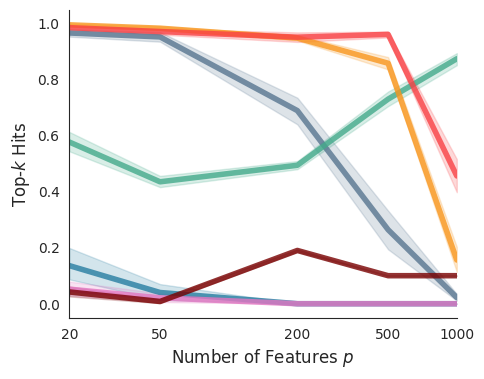

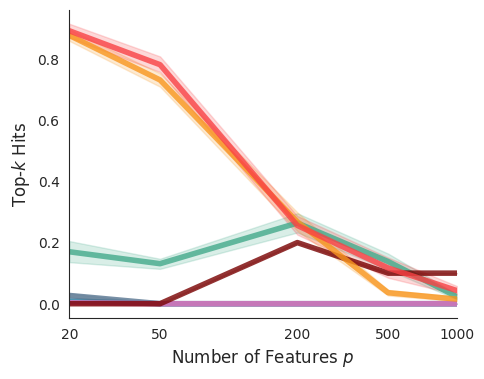

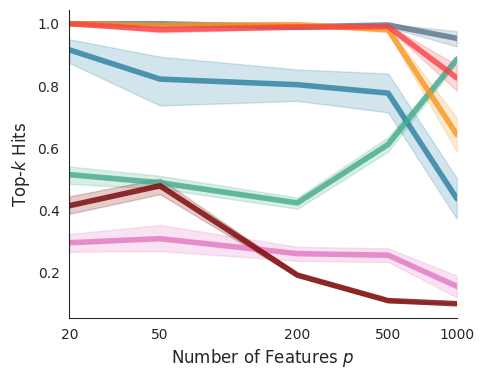

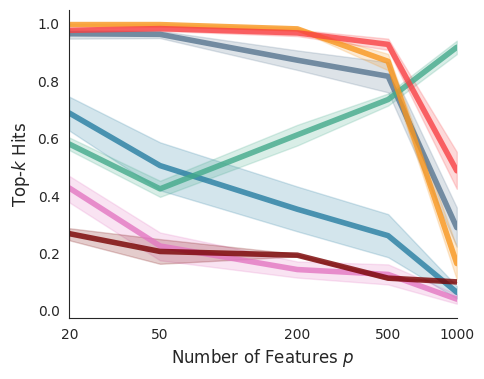

In [8]:
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'easy', title='', figsize=(5, 4), base_clusterer ='KMeans', save_file='../figures/supp4_GMM_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gaussian', 'medium', title='', figsize=(5, 4),base_clusterer ='KMeans',  save_file='../figures/supp4_GMM_harder.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'easy', figsize=(5, 4),base_clusterer ='Gamma Mixture',  save_file='../figures/supp4_GammaMM_easier.pdf') #  title='Gamma mixture (easier)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'gamma', 'medium', base_clusterer ='Gamma Mixture', figsize=(5, 4), save_file='../figures/supp4_GammaMM_harder.pdf') #  title='Gamma mixture (harder)',
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'easy', title='', figsize=(5, 4), base_clusterer ='Spectral Clustering', save_file='../figures/supp4_MC_easier.pdf')
plt.show()
fig, ax = get_lineplot_parentheses_labels(df_avg, 'moon', 'medium',  figsize=(5, 4),base_clusterer ='Spectral',   save_file='../figures/supp4_MC_harder.pdf')#  title='Moons and Circles (harder)',
plt.show()

# Minipatch size empirical results

In [114]:
import os
import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import sys
sys.path.append('../')
from clim.models.sklearn_wrappers import *
from clim.simulations.simulators import *
from clim.minipatches.fast_g import *
from clim.minipatches.rampart import *
from clim.non_conformity_scores import *


def make_feasible_alpha_grid(
    p,
    N,
    alpha_N_values=None,
    alpha_M_values=None,
    alpha_min=0.1,
    alpha_max=0.5,
    strict=True,
):
    if alpha_N_values is None:
        alpha_N_values = np.round(np.linspace(alpha_min, alpha_max, 5), 3)

    if alpha_M_values is None:
        alpha_M_values = np.round(np.linspace(alpha_min, alpha_max, 5), 3)

    rows = []

    for alpha_N in alpha_N_values:
        for alpha_M in alpha_M_values:
            n_patch = int(np.floor(alpha_N * N))
            m_patch = int(np.floor(alpha_M * p))

            feasible = n_patch > m_patch if strict else n_patch >= m_patch

            if feasible:
                rows.append({
                    "alpha_N": float(alpha_N),
                    "alpha_M": float(alpha_M),
                    "n_patch": n_patch,
                    "m_patch": m_patch,
                    "ratio_n_over_m": n_patch / max(m_patch, 1),
                })

    return pd.DataFrame(rows)

In [108]:
grid = make_feasible_alpha_grid(
    p=100,
    N=300,
    alpha_N_values=np.round(np.linspace(0.1, 0.5, 9), 2),
    alpha_M_values=np.round(np.linspace(0.1, 0.5, 9), 2),
)

grid.head()

,alpha_N,alpha_M,n_patch,m_patch,ratio_n_over_m
0,0.10,0.10,30,10,3.0
1,0.10,0.15,30,15,2.0
2,0.10,0.20,30,20,1.5
3,0.10,0.25,30,25,1.2
4,0.15,0.10,45,10,4.5


In [115]:
def run_one_alpha_pair(
    *,
    X_aug,
    y,
    K,
    informative_d,
    base_clusterer,
    alpha_N,
    alpha_M,
    B_cloc=5000,
    B_ramp=1000,
    topk=None,
    standardize=True,
    run_cloc=True,
    run_rampart=False,
    n_jobs=8,
):
    N, p = X_aug.shape

    if topk is None:
        topk = informative_d

    true_idx = np.arange(informative_d)

    n_patch = int(np.floor(alpha_N * N))
    m_patch = int(np.floor(alpha_M * p))

    result = {
        "alpha_N": float(alpha_N),
        "alpha_M": float(alpha_M),
        "n_patch": n_patch,
        "m_patch": m_patch,
        "ratio_n_over_m": n_patch / max(m_patch, 1),
        "feasible": bool(n_patch > m_patch),
        "topk_cloc": np.nan,
        "topk_rampart": np.nan,
        "ari_cloc": np.nan,
        "ari_rampart": np.nan,
        "time_cloc": np.nan,
        "time_rampart": np.nan,
    }

    if n_patch <= m_patch:
        return result

    if run_cloc:
        g = ClusterLOCOMP(
            base_clusterer=clone(base_clusterer),
            K=K,
        )

        t0 = time.perf_counter()

        g.fit(
            X_aug,
            B=B_cloc,
            alpha_M=alpha_M,
            alpha_N=alpha_N,
            standardize=standardize,
            parallel={"n_jobs_features": n_jobs},
        )

        cloc_out = g.score(hinge_error)
        result["time_cloc"] = time.perf_counter() - t0

        if isinstance(cloc_out, dict) and "delta" in cloc_out:
            cloc_raw = np.asarray(cloc_out["delta"], dtype=float).reshape(-1)
        else:
            cloc_raw = np.asarray(cloc_out, dtype=float).reshape(-1)

        if cloc_raw.size != p:
            raise ValueError(
                f"ClusterLOCOMP returned {cloc_raw.size} features, expected {p}"
            )

        result["topk_cloc"] = topk_overlap(
            cloc_raw,
            true_idx=true_idx,
            k=topk,
        )

        result["ari_cloc"] = adjusted_rand_score(y, g.z_test)

    if run_rampart:
        gen_fn = ClusterLOCO_RAMPART(
            K=K,
            base_clusterer=clone(base_clusterer),
            error_metric=hinge_error,
            alpha_N=alpha_N,
            alpha_M=alpha_M,
            parallel_MP=True,
            parallel={
                "n_jobs_features": n_jobs,
                "backend": "loky",
                "prefer": "processes",
                "verbose": 0,
            },
            standardize=standardize,
            z_for_score="z_test",
        )

        t0 = time.perf_counter()

        ramp_out = RAMPART(
            X_aug,
            generalizability_fn=gen_fn,
            B=B_ramp,
            ranking_fn=transform_scores_to_ranking,
            top_k=topk,
            gen_kwargs={},
        )

        result["time_rampart"] = time.perf_counter() - t0

        selected_idx = np.asarray(ramp_out["selected_indices"], dtype=int)

        result["topk_rampart"] = (
            np.intersect1d(selected_idx, true_idx, assume_unique=False).size / topk
        )

        result["ari_rampart"] = adjusted_rand_score(y, ramp_out["z_i"])

    return result

In [116]:
def run_alpha_sweep_one_dataset(
    *,
    X_aug,
    y,
    K,
    informative_d,
    base_clusterer,
    alpha_N_values=None,
    alpha_M_values=None,
    B_cloc=5000,
    B_ramp=1000,
    topk=None,
    standardize=True,
    run_cloc=True,
    run_rampart=False,
    n_jobs=8,
    verbose=True,
):
    N, p = X_aug.shape

    alpha_grid = make_feasible_alpha_grid(
        p=p,
        N=N,
        alpha_N_values=alpha_N_values,
        alpha_M_values=alpha_M_values,
        strict=True,
    )

    if verbose:
        print(f"N={N}, p={p}")
        print(f"Feasible alpha pairs: {len(alpha_grid)}")
        display(alpha_grid)

    rows = []

    for idx, row in alpha_grid.iterrows():
        if verbose:
            print(
                f"[{idx + 1}/{len(alpha_grid)}] "
                f"alpha_N={row['alpha_N']}, alpha_M={row['alpha_M']}, "
                f"n_patch={row['n_patch']}, m_patch={row['m_patch']}"
            )

        out = run_one_alpha_pair(
            X_aug=X_aug,
            y=y,
            K=K,
            informative_d=informative_d,
            base_clusterer=base_clusterer,
            alpha_N=float(row["alpha_N"]),
            alpha_M=float(row["alpha_M"]),
            B_cloc=B_cloc,
            B_ramp=B_ramp,
            topk=topk,
            standardize=standardize,
            run_cloc=run_cloc,
            run_rampart=run_rampart,
            n_jobs=n_jobs,
        )

        rows.append(out)

    return pd.DataFrame(rows)

In [120]:
def run_alpha_sweep_simulations(
    *,
    cfg,
    n_sims=5,
    global_seed=123,
    alpha_N_values=None,
    alpha_M_values=None,
    run_cloc=True,
    run_rampart=False,
    n_jobs=8,
    verbose=True,
):
    sim_method = cfg.get("sim_method", "non-gaussian")
    K = int(cfg["K"])
    informative_d = int(cfg["informative_d"])
    topk = int(cfg.get("topk", informative_d))

    noise_plan = list(cfg["noise_plan"])
    noise_d = int(sum(int(block["d"]) for block in noise_plan))

    if sim_method in ["moon-donut", "swiss-roll"]:
        base_clusterer = BaseSpectralClustering(n_clusters=K)
    else:
        base_clusterer = KMeans(n_clusters=K)

    all_results = []

    for sim_id in range(n_sims):
        if verbose:
            print("=" * 80)
            print(f"Simulation {sim_id + 1}/{n_sims}")
            print("=" * 80)

        sim_seed = global_seed + sim_id
        embed_seed = global_seed + 100_000 + sim_id

        X_aug, y = generate_dataset_for_one_run(
            sim_method=sim_method,
            sim_seed=sim_seed,
            embed_seed=embed_seed,
            K=K,
            n_per_cluster=int(cfg["n_per_cluster"]),
            alpha=float(cfg["alpha"]),
            d0=int(cfg["d0"]),
            gaps=cfg["gaps"],
            shape_probs=cfg["shape_probs"],
            oversample=float(cfg["oversample"]),
            informative_d=informative_d,
            noise_plan=noise_plan,
        )

        sweep_df = run_alpha_sweep_one_dataset(
            X_aug=X_aug,
            y=y,
            K=K,
            informative_d=informative_d,
            base_clusterer=base_clusterer,
            alpha_N_values=alpha_N_values,
            alpha_M_values=alpha_M_values,
            B_cloc=int(cfg.get("B", 5000)),
            B_ramp=int(cfg.get("B_ramp", 1000)),
            topk=topk,
            standardize=bool(cfg.get("standardize", True)),
            run_cloc=run_cloc,
            run_rampart=run_rampart,
            n_jobs=n_jobs,
            verbose=verbose,
        )

        sweep_df["sim_id"] = sim_id
        sweep_df["sim_method"] = sim_method
        sweep_df["N"] = X_aug.shape[0]
        sweep_df["p"] = X_aug.shape[1]
        sweep_df["K"] = K
        sweep_df["informative_d"] = informative_d
        sweep_df["noise_d"] = noise_d
        sweep_df["topk"] = topk

        all_results.append(sweep_df)

    return pd.concat(all_results, ignore_index=True)

def topk_overlap(scores, true_idx, k, signed=False):
    s = np.asarray(scores, dtype=float).reshape(-1)
    topk = np.argsort(s)[::-1][:k]
    hits = np.intersect1d(topk, true_idx, assume_unique=False).size # intersection selection and top k
    return hits/k


def generate_dataset_for_one_run(
    *,
    sim_method: str,
    sim_seed: int,
    embed_seed: int,
    K: int,
    n_per_cluster: int,
    alpha: float,
    d0: int,
    gaps,
    shape_probs,
    oversample: float,
    informative_d: int,
    noise_plan: list,
):
    """
    noise_plan: list of dicts like:
      [{"type":"gaussian","d":10},
       {"type":"student-t","d":10,"df":10},
       {"type":"triangular","d":10,"low":-1,"high":1},
       {"type":"laplace","d":10,"scale":1.0}]
    """
    # Adds correlation in signal
    Cov_k = [GenerateCovariances(dim=d0, covMethod='onion', eta=1/(k+1)).covGen()[0] for k in range(K)]

    sim = BaseSimulator(
        K=K,
        n_samples_per_cluster=n_per_cluster,
        alpha=alpha,
        d_0=d0,
        method=sim_method,
        gaps=gaps,
        shape_probs=shape_probs,
        oversample=oversample,
        random_state=sim_seed,
    )
    X, y = sim.generate_data()

    # project to informative dims with embed_seed
    rng_saved = sim.rng
    sim.rng = np.random.default_rng(embed_seed)
    if informative_d - d0 > 0:
        sim.project_higher_dim(embed_dim=informative_d-d0, method='orthogonal', gamma=1, degree=5, label_aware=True)
    sim.rng = rng_saved

    # sequentially append noise blocks
    for block in noise_plan:
        nt = block["type"]
        d = int(block["d"])
        kw = {k: v for k, v in block.items() if k not in ("type", "d")}
        if nt=='permuted':
            random_features = np.random.choice(np.arange(sim.X.shape[1]), size=d)
            X_noise = np.array([permute_feature(sim.X, rd_feat) for rd_feat in random_features]).T
            sim.X = np.concatenate([sim.X, X_noise], axis=1)
        elif nt =='uniform':
            sim.add_noise(noise_d=d, noise_type=nt, low=np.min(sim.X), high=np.max(sim.X))
        else:
            sim.add_noise(noise_d=d, noise_type=nt, **kw)
    X_aug = sim.X

    if sim_method == 'moon-donut':
        X_aug = np.concatenate([X, X_aug], axis=1) 
    elif sim_method == 'swiss-roll':
        X_aug = np.concatenate([X, X_aug], axis=1) 
    return X_aug, y
    

In [121]:
cfg = {
    "sim_method": "moon-donut",
    "K": 3,
    "n_per_cluster": 100,
    "informative_d": 10,
    "topk": 10,
    "alpha": 1.0,
    "d0": 2,
    "gaps": [0.2, 0.2, 0.2],
    "shape_probs": {"donut": 0.5, "moon": 0.5},
    "oversample": 10,
    "noise_plan": [
        {"type": "gaussian", "d": 40}
    ],
    "B": 5000,
    "B_ramp": 1000,
    "standardize": True,
}

In [122]:
alpha_N_values = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
alpha_M_values = np.array([0.1, 0.2, 0.3, 0.4, 0.5])

res = run_alpha_sweep_simulations(
    cfg=cfg,
    n_sims=3,
    global_seed=123,
    alpha_N_values=alpha_N_values,
    alpha_M_values=alpha_M_values,
    run_cloc=True,
    run_rampart=False,   # start with False because RAMPART is expensive
    n_jobs=8,
    verbose=False,
)

---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches training ------------
---------- Computes LOO -----------
---------- Computes LOCO-LOO -----------
---------- Minipatches t

In [123]:
os.makedirs("../results/", exist_ok=True)

res.to_csv(
    "../results/moon_donut_alpha_sweep.csv",
    index=False
)

In [124]:
summary = (
    res
    .groupby(["alpha_N", "alpha_M", "n_patch", "m_patch"], as_index=False)
    .agg(
        topk_cloc_mean=("topk_cloc", "mean"),
        topk_cloc_sd=("topk_cloc", "std"),
        ari_cloc_mean=("ari_cloc", "mean"),
        time_cloc_mean=("time_cloc", "mean"),
        topk_rampart_mean=("topk_rampart", "mean"),
        topk_rampart_sd=("topk_rampart", "std"),
        ari_rampart_mean=("ari_rampart", "mean"),
        time_rampart_mean=("time_rampart", "mean"),
    )
)

summary

,alpha_N,alpha_M,n_patch,m_patch,topk_cloc_mean,topk_cloc_sd,ari_cloc_mean,time_cloc_mean,topk_rampart_mean,topk_rampart_sd,ari_rampart_mean,time_rampart_mean
0,0.1,0.1,30,5,1.000000,0.000000,0.625972,39.413555,NaN,NaN,NaN,NaN
1,0.1,0.2,30,10,1.000000,0.000000,0.629130,39.159427,NaN,NaN,NaN,NaN
2,0.1,0.3,30,15,1.000000,0.000000,0.627773,40.867927,NaN,NaN,NaN,NaN
3,0.1,0.4,30,20,1.000000,0.000000,0.622541,43.267522,NaN,NaN,NaN,NaN
4,0.1,0.5,30,25,0.966667,0.057735,0.621876,39.909022,NaN,NaN,NaN,NaN
5,0.2,0.1,60,5,1.000000,0.000000,0.626944,39.704949,NaN,NaN,NaN,NaN
6,0.2,0.2,60,10,1.000000,0.000000,0.631505,38.333001,NaN,NaN,NaN,NaN
7,0.2,0.3,60,15,1.000000,0.000000,0.625422,38.435529,NaN,NaN,NaN,NaN
8,0.2,0.4,60,20,1.000000,0.000000,0.620670,39.013411,NaN,NaN,NaN,NaN
9,0.2,0.5,60,25,1.000000,0.000000,0.619754,38.858062,NaN,NaN,NaN,NaN


In [125]:
import matplotlib.pyplot as plt

def plot_alpha_heatmap(res, value_col, title=None, vmin=0, vmax=1):
    heat = (
        res
        .groupby(["alpha_N", "alpha_M"])[value_col]
        .mean()
        .reset_index()
        .pivot(index="alpha_N", columns="alpha_M", values=value_col)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        heat.values,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns)

    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)

    ax.set_xlabel(r"$\alpha_M$")
    ax.set_ylabel(r"$\alpha_N$")
    ax.set_title(title or value_col)

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()

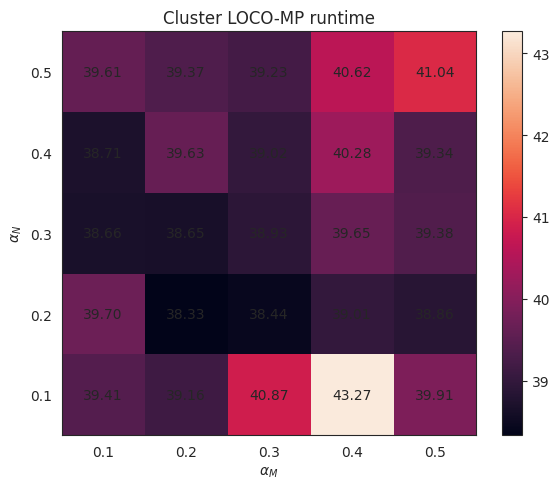

In [126]:
plot_alpha_heatmap(
    res,
    value_col="time_cloc",
    title="Cluster LOCO-MP runtime",
    vmin=None,
    vmax=None
)

In [127]:
print("hello")

hello


In [131]:
import numpy as np
import matplotlib.pyplot as plt

def plot_topk_by_mpatch_faceted_npatch(
    summary,
    y_col="topk_cloc_mean",
    y_sd_col="topk_cloc_sd",
    title="Top-k recovery by feature minipatch size",
):
    facets = sorted(summary["n_patch"].dropna().unique())

    n_facets = len(facets)
    ncols = min(4, n_facets)
    nrows = int(np.ceil(n_facets / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )

    axes = np.asarray(axes).reshape(-1)

    for ax, n_val in zip(axes, facets):
        sub = (
            summary[summary["n_patch"] == n_val]
            .sort_values("m_patch")
        )

        x = sub["m_patch"].values
        y = sub[y_col].values

        ax.plot(x, y, marker="o")

        if y_sd_col is not None and y_sd_col in sub.columns:
            sd = sub[y_sd_col].fillna(0).values
            ax.fill_between(x, y - sd, y + sd, alpha=0.15)

        ax.set_title(rf"$n_{{patch}} = {n_val}$")
        ax.set_xlabel(r"$m_{patch}$")
        ax.set_ylabel("Top-k recovery")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.25)

    for ax in axes[len(facets):]:
        ax.axis("off")

    fig.suptitle(title, fontweight="bold", y=1.02)
    fig.tight_layout()

    return fig, axes

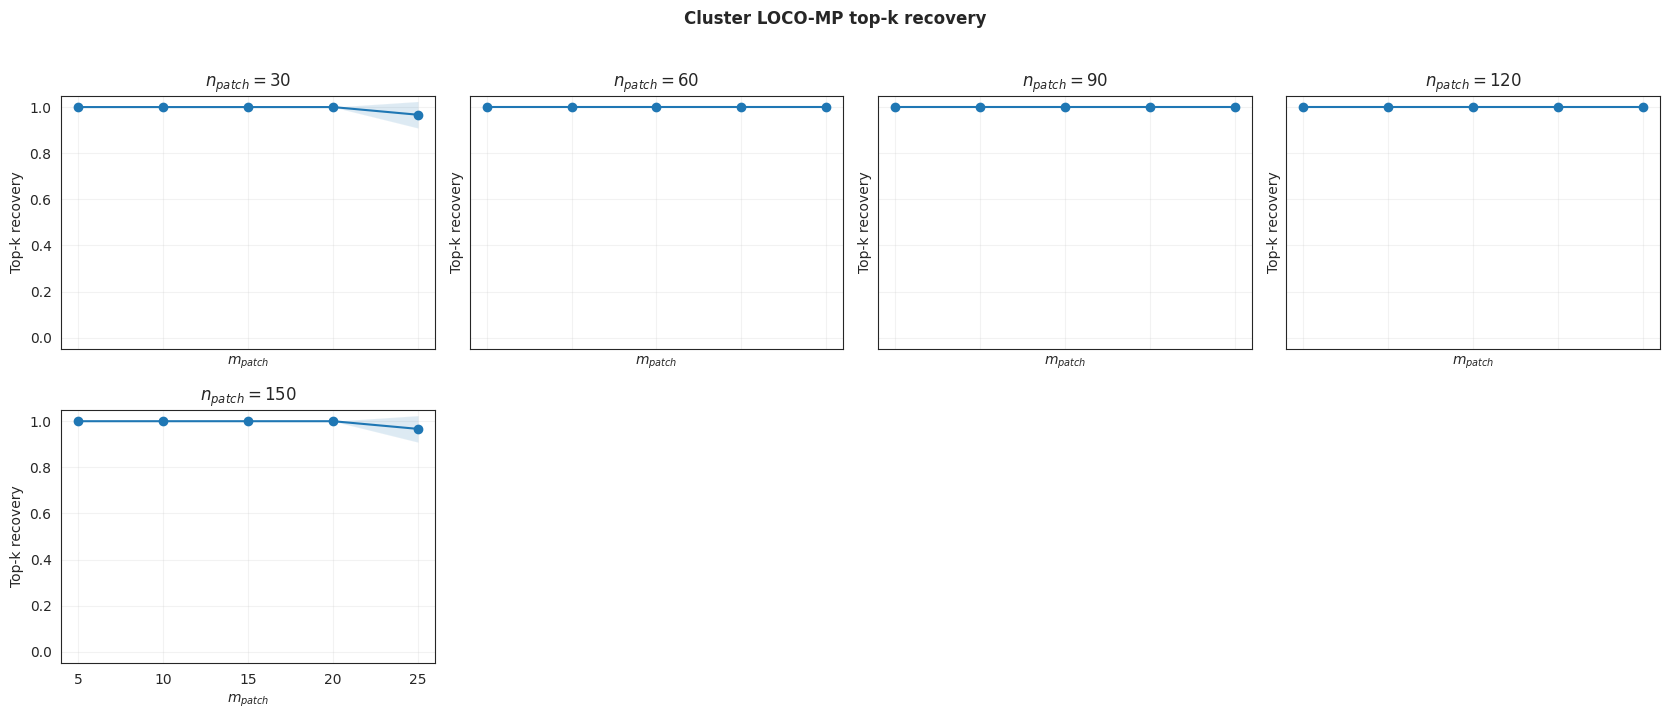

In [132]:
fig, axes = plot_topk_by_mpatch_faceted_npatch(
    summary,
    y_col="topk_cloc_mean",
    y_sd_col="topk_cloc_sd",
    title="Cluster LOCO-MP top-k recovery"
)

plt.show()